In [578]:
# 1. pandas se csv file ko read karenge
# 2. data understanding like describe,tail,head,info,data types,column name rename
# 3. duplicate remove
# 4. domain ke hisab se features remove kar denge
# 5. data cleaning & others like 
#     1. missing values
#         1. pattern find - MCAR,MNAR,MAR
#         2. pattern ke hisab se fill = 
#             1. MCAR - mean/median, mode using groupby or not
#             2. MAR = knn, group by, fill forward, fill backword, constant value, remove row,remove column,etc...
#             3. MNAR = domain knowledge
#             4. maximum domain knowledge
#     2. outliars handle
#         outliars find
#             1. matplotlib - box plot,scatter plot, kde, histogram
#             2. data normal distributed = z-score - upper | lower boundry found
#             3. not data normal distributed = iqr - upper | lower boundry found
#             4. mutual information - relation ke hisab se outliars 
#         outliars fill
#             1. clip
#             2. remove
#             3. transformation
#                 - log, squre, squre root, 1/x, box-cox, yo-johnson
#             4. domain knowledge maximum
#     3. scalling - distance based algorithm like linear,gradient decent,etc...
#         1. z-score = scalling = range na pata ho
#         2. min max = normalization = range pata ho
#         3. robust  = normalization = range pata ho
#     4. feature engineering
#         1. domain knowledge
#         2. feature selection
#             1. variance
#             2. co relation 
#             3. non linear relation find karke selection
#             4. inbuilt models like decision tree, random forest, etc.. 
#         3. feature extraction
#             1. LDA
#             2. PCA
#         4. feature creation as per domain knowledge
#     5. Train Test split = x_train,y_train = fit training
#                         = x_test,y_test = testing = error 
#                         y_test = y_predected
#                         difference - error
# 6. model selection as per requirments, problems, domain knowledge
#     like regression, classification or unsupervised models

#     1. regression

#         1. linear

In [579]:
import pandas as pd
import numpy as np

# Find detalis from Data

In [580]:
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [581]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [582]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [583]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [584]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [585]:
df.shape

(20640, 10)

In [586]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [587]:
df.duplicated().sum()

np.int64(0)

# Handling Missing Value

In [588]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [589]:
df.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [590]:
df['total_bedrooms'].median()

np.float64(435.0)

In [591]:
# total bedroom colum fill with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(  df['total_bedrooms'].median())

In [592]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Find Outliers and Handle

In [593]:
# find outliers
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    percentage = (outliers / len(df)) * 100

    print(col, ":", outliers, "outliers |", round(percentage, 2), "%")

longitude : 0 outliers | 0.0 %
latitude : 0 outliers | 0.0 %
housing_median_age : 0 outliers | 0.0 %
total_rooms : 1287 outliers | 6.24 %
total_bedrooms : 1306 outliers | 6.33 %
population : 1196 outliers | 5.79 %
households : 1220 outliers | 5.91 %
median_income : 681 outliers | 3.3 %
median_house_value : 1071 outliers | 5.19 %


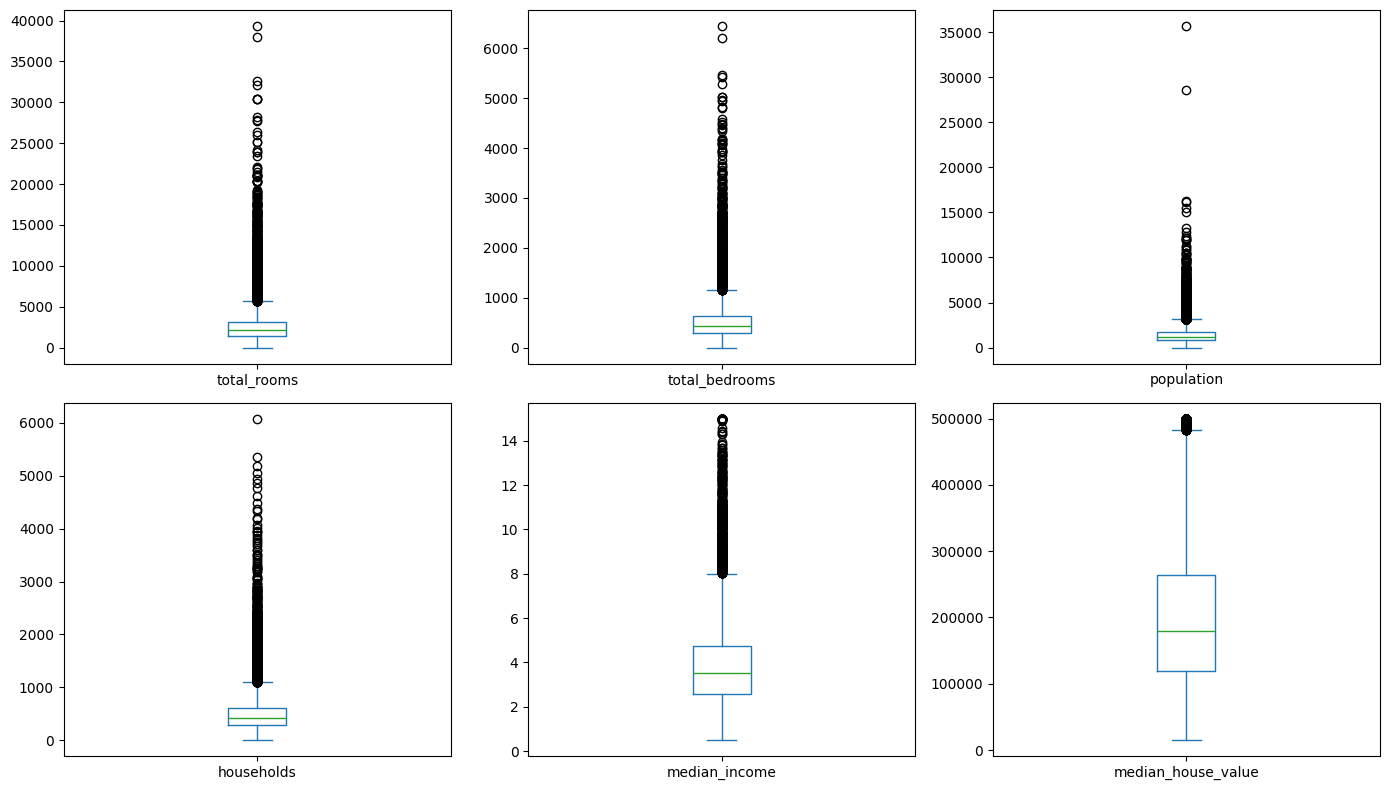

In [594]:
import matplotlib.pyplot as plt
#Better analysis: outlier wale columns ke individual boxplots bana.

outlier_cols = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'median_house_value'
]

# Before transformation
df[outlier_cols].plot(
    kind='box',
    subplots=True,
    layout=(2, 3),
    figsize=(14, 8)
)

plt.tight_layout()
plt.show()

In [595]:
outlier_percentage = (outliers / len(df)) * 100

outlier_percentage

np.float64(5.188953488372093)

In [596]:
df[numeric_cols].skew().sort_values(ascending=False)

population            4.935858
total_rooms           4.147343
total_bedrooms        3.481141
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
dtype: float64

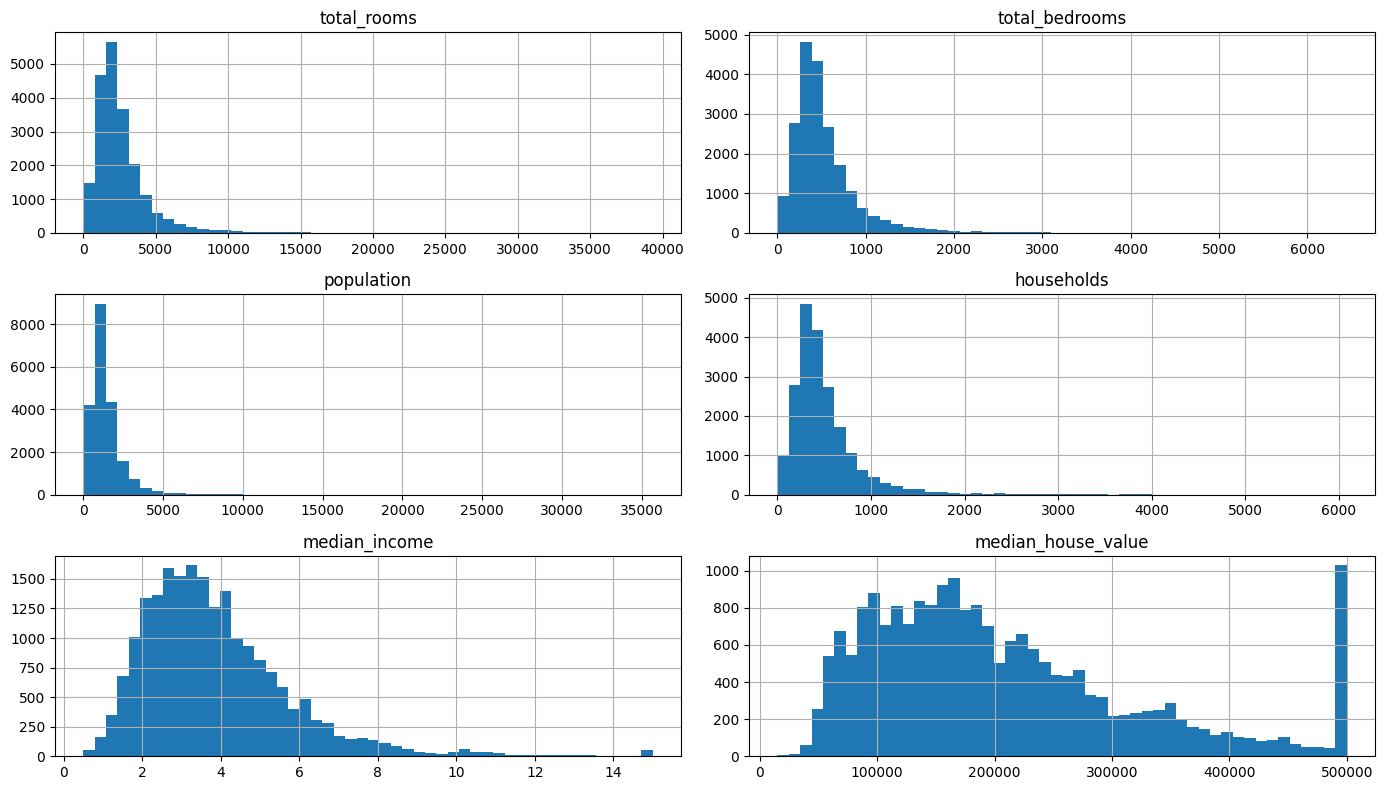

In [597]:

import matplotlib.pyplot as plt

outlier_cols = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'median_house_value'
]

df[outlier_cols].hist(
    bins=50,
    figsize=(14, 8)
)

plt.tight_layout()
plt.show()

In [598]:
from sklearn.preprocessing import PowerTransformer

transform_cols = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'median_house_value'
]

pt = PowerTransformer(method='yeo-johnson')

df_transformed = df.copy()

df_transformed[transform_cols] = pt.fit_transform(
    df_transformed[transform_cols]
)

In [599]:
pd.DataFrame({
    'Before_total_rooms': df['total_rooms'].head(10).values,
    'After_total_rooms': df_transformed['total_rooms'].head(10).values,

    'Before_total_bedrooms': df['total_bedrooms'].head(10).values,
    'After_total_bedrooms': df_transformed['total_bedrooms'].head(10).values,

    'Before_population': df['population'].head(10).values,
    'After_population': df_transformed['population'].head(10).values,

    'Before_households': df['households'].head(10).values,
    'After_households': df_transformed['households'].head(10).values,

    'Before_median_income': df['median_income'].head(10).values,
    'After_median_income': df_transformed['median_income'].head(10).values,

    'Before_median_house_value': df['median_house_value'].head(10).values,
    'After_median_house_value': df_transformed['median_house_value'].head(10).values
}).round(3)

,Before_total_rooms,After_total_rooms,Before_total_bedrooms,After_total_bedrooms,Before_population,After_population,Before_households,After_households,Before_median_income,After_median_income,Before_median_house_value,After_median_house_value
0,880.0,-1.158,129.0,-1.580,322.0,-1.620,126.0,-1.521,8.325,1.903,452600.0,1.718
1,7099.0,1.896,1106.0,1.445,2401.0,1.090,1138.0,1.634,8.301,1.897,358500.0,1.263
2,1467.0,-0.535,190.0,-1.136,496.0,-1.140,177.0,-1.136,7.257,1.604,352100.0,1.228
3,1274.0,-0.714,235.0,-0.875,558.0,-1.000,219.0,-0.879,5.643,1.051,341300.0,1.169
4,1627.0,-0.400,280.0,-0.650,565.0,-0.985,259.0,-0.666,3.846,0.206,342200.0,1.174
5,919.0,-1.108,213.0,-0.997,413.0,-1.349,193.0,-1.033,4.037,0.312,269700.0,0.725
6,2535.0,0.215,489.0,0.125,1094.0,-0.124,514.0,0.298,3.659,0.097,299200.0,0.919
7,3104.0,0.516,687.0,0.646,1157.0,-0.045,647.0,0.659,3.120,-0.250,241400.0,0.520
8,2555.0,0.227,665.0,0.594,1206.0,0.015,595.0,0.525,2.080,-1.105,226700.0,0.406
9,3549.0,0.723,707.0,0.692,1551.0,0.388,714.0,0.820,3.691,0.116,261100.0,0.665


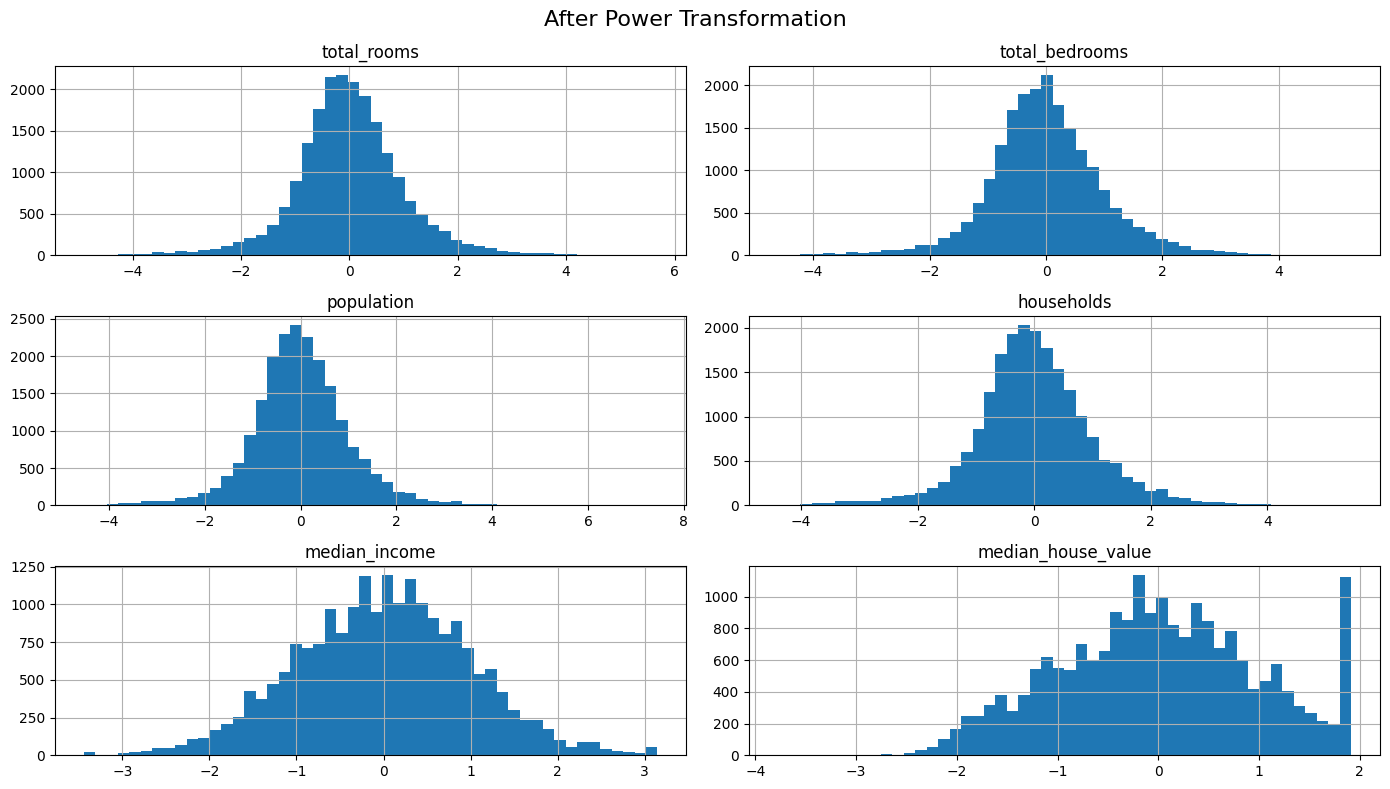

In [600]:
import matplotlib.pyplot as plt

df_transformed[transform_cols].hist(
    bins=50,
    figsize=(14, 8)
)

plt.suptitle("After Power Transformation", fontsize=16)
plt.tight_layout()
plt.show()

# Feature engeneering

In [601]:
#1. rooms_per_household
df['rooms_per_household'] = df['total_rooms'] / df['households']
#2. bedrooms_per_room
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
#3. population_per_household
df['population_per_household'] = df['population'] / df['households']

In [602]:
df[['rooms_per_household',
   'bedrooms_per_room',
   'population_per_household']].head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


# Feature selection

In [603]:
#1. Variance check

X = df.drop('median_house_value', axis=1)

variance = X.select_dtypes(include='number').var()

variance.sort_values()

bedrooms_per_room           4.257323e-03
median_income               3.609323e+00
longitude                   4.014139e+00
latitude                    4.562293e+00
rooms_per_household         6.121533e+00
population_per_household    1.078700e+02
housing_median_age          1.583963e+02
households                  1.461760e+05
total_bedrooms              1.758895e+05
population                  1.282470e+06
total_rooms                 4.759445e+06
dtype: float64

In [604]:
#2. Correlation with target

correlation = df.select_dtypes(include='number').corr()['median_house_value']

correlation.sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049457
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.233303
Name: median_house_value, dtype: float64

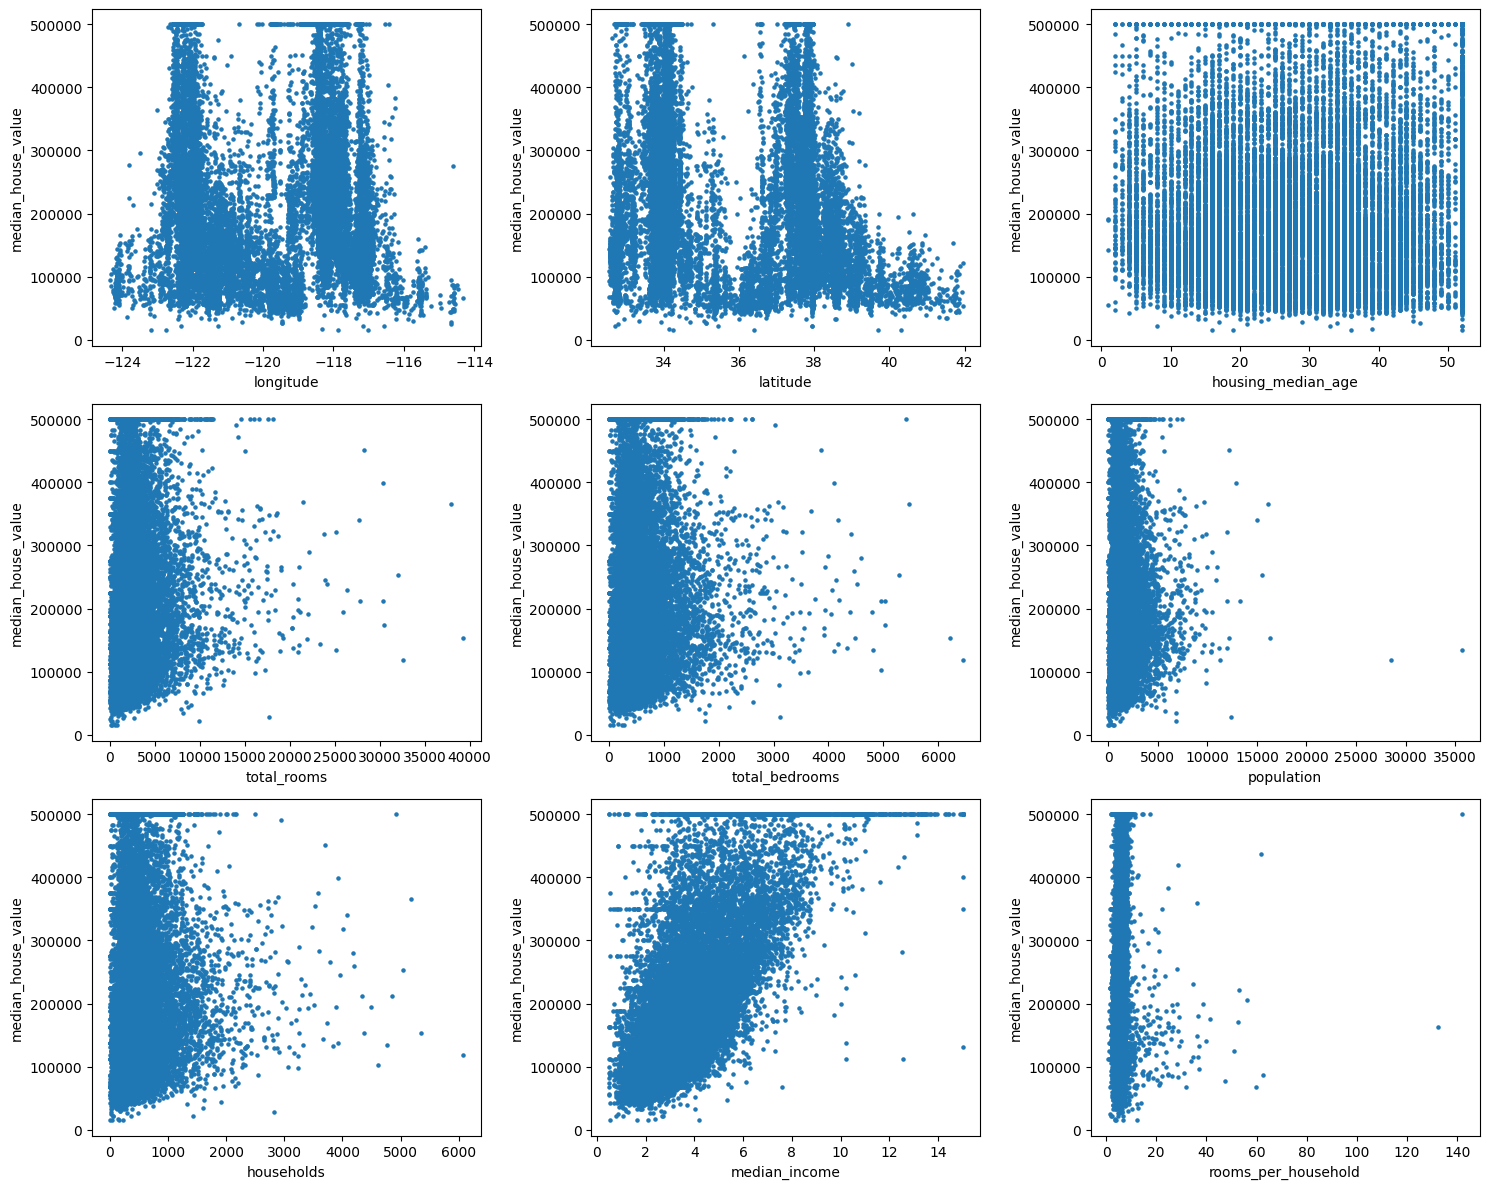

In [605]:
#3. Non-linear relationship

import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns.drop(
    'median_house_value'
)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, numeric_cols):
    ax.scatter(df[col], df['median_house_value'], s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('median_house_value')

plt.tight_layout()
plt.show()

# Mutual correlation matrix

In [606]:
corr_matrix = df.select_dtypes(include='number').drop(
    'median_house_value', axis=1
).corr()

corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.027540,0.081205,0.002476
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,0.106389,-0.098619,0.002366
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,-0.153277,0.135622,0.013191
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.133798,-0.187381,-0.024581
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.001765,0.071649,-0.028325
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.072213,0.010035,0.069863
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,-0.080598,0.034498,-0.027309
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.326895,-0.545298,0.018766
rooms_per_household,-0.027540,0.106389,-0.153277,0.133798,0.001765,-0.072213,-0.080598,0.326895,1.000000,-0.370308,-0.004852
bedrooms_per_room,0.081205,-0.098619,0.135622,-0.187381,0.071649,0.010035,0.034498,-0.545298,-0.370308,1.000000,0.002601


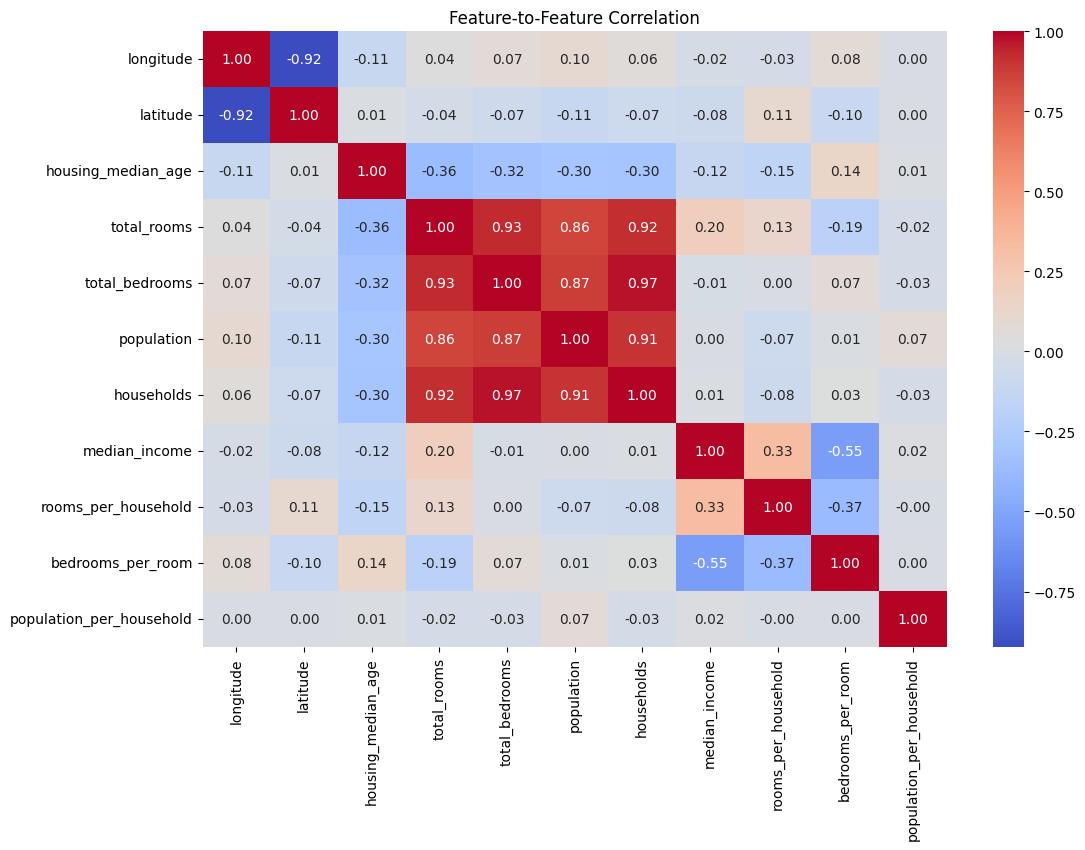

In [607]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature-to-Feature Correlation")
plt.show()

In [608]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    print("\n", col)
    print(df[col].describe())


 longitude
count    20640.000000
mean      -119.569704
std          2.003532
min       -124.350000
25%       -121.800000
50%       -118.490000
75%       -118.010000
max       -114.310000
Name: longitude, dtype: float64

 latitude
count    20640.000000
mean        35.631861
std          2.135952
min         32.540000
25%         33.930000
50%         34.260000
75%         37.710000
max         41.950000
Name: latitude, dtype: float64

 housing_median_age
count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

 total_rooms
count    20640.000000
mean      2635.763081
std       2181.615252
min          2.000000
25%       1447.750000
50%       2127.000000
75%       3148.000000
max      39320.000000
Name: total_rooms, dtype: float64

 total_bedrooms
count    20640.000000
mean       536.838857
std        419.391878
min          1.00

In [609]:
df.to_csv('cleaned_housing.csv', index=False)

In [610]:
df['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str